# Week 8 - LDA and constrained optimization (solution)

Learning contents:

* FDA (2 classes)
    * Compute the class means (in PCA space)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection vector $\mathbf{w}$
    * Compute and plot the 1D projection of the data
    * Compute the class separation of the projected values
* LDA (3 classes)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection matrix $\mathbf{W}$
    * Compute and plot the 2D projection of the data
    * Compute the 2D LDA projection of the original 64D data
* Constrained Optimization
    * Reformulate the problem as a maximization problem
    * Write out the Lagrangian function
    * Compute the gradients with respects to $x_1, x_2$, Lagrange multiplier $\lambda$ and the KKT multiplier $\mu$
    * Compute the optimum

In [1]:
# Dependencies
import numpy as np
import scipy
import scipy.linalg
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns; sns.set_theme(); sns.set_palette('bright')

## Data
As usual, we'll be working with a dataset of handwritten digits.
Let visualise some examples.

In [2]:
# We're using a subset of two classes for now
digits = load_digits(n_class=2)

In [3]:
# Handy plotting functions

def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, alpha=0.5, legend=True,w=None):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

    if w is not None:
        # w is a 2-D FDA direction vector (no bias term). The decision boundary
        # is the line perpendicular to w through the midpoint of the two class means.
        labels = np.unique(target)
        m1 = np.mean(data[target == labels[0]], axis=0)
        m2 = np.mean(data[target == labels[1]], axis=0)
        m_mid = (m1 + m2) / 2

        x_values = np.linspace(np.min(data[:, 0]), np.max(data[:, 0]), 100)
        # Perpendicular to w through m_mid: w[0]*(x - m_mid[0]) + w[1]*(y - m_mid[1]) = 0
        y_values = m_mid[1] - (w[0] / w[1]) * (x_values - m_mid[0])

        plt.plot(x_values, y_values, color='red', label='Decision boundary')
    #plt.show()

def plot_scatter3d(data, targets, view_point=(25, 45), alpha=0.5, legend=True):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(data[:,0], data[:,1], data[:,2], c=targets, cmap="rainbow", alpha=alpha)
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    ax.view_init(*view_point) # <- change viewpoint here
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()

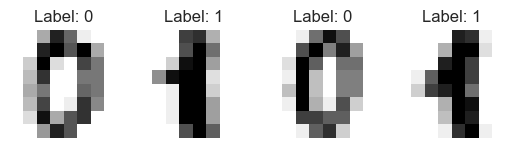

In [4]:
plot_examples()

In [5]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with
t = digits.target

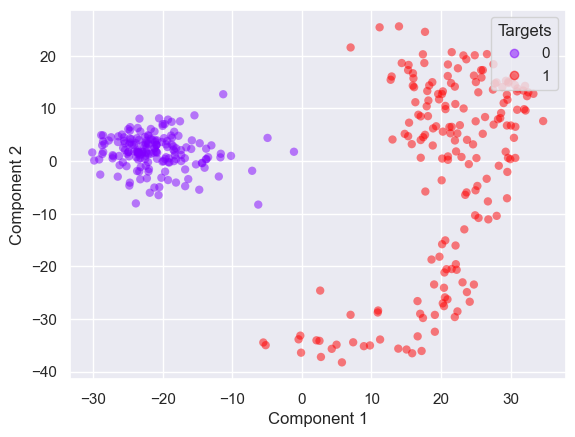

In [6]:
# Let's plot all the data in 2D
plot_scatter(X, t)

## 1) Fisher Discriminant Analysis (FDA)


### 1.1) Compute the class means (in PCA space)

In [7]:
def class_mean(data, targets, label):
    return np.sum(data[targets==label], axis=0) / np.sum(targets==label)

m = np.array([class_mean(X, t, lbl) for lbl in [0,1]])

print("Mean for class 0: {}".format(m[0]))
print("Mean for class 1: {}".format(m[1]))

Mean for class 0: [-21.14447038   1.75335626]
Mean for class 1: [20.67975675 -1.71482096]


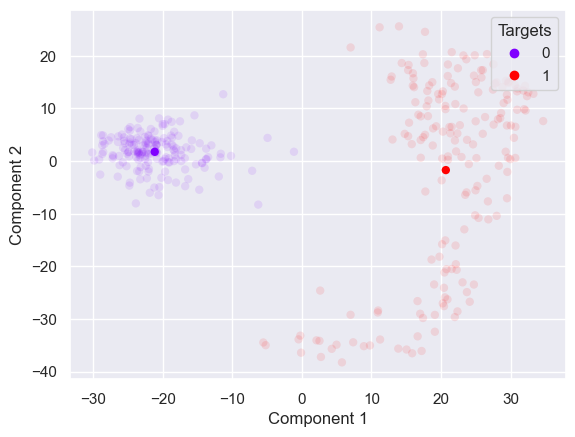

In [8]:
plot_scatter(X, t, alpha=0.1)
plot_scatter(m, [0,1], alpha=1)
plt.show()

### 1.2) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
Use eq (4.27) and (4.28) from textbook for computing $\mathbf{S}_B$ and $\mathbf{S}_W$ respectively

In [9]:
mean = np.expand_dims(m,axis=1)

S_B = (mean[1] - mean[0])*(mean[1] - mean[0]).T

S_W = sum([
    (X[t==lbl] - mean[lbl]).T @ (X[t==lbl] - mean[lbl])
    for lbl in range(2)
])


print("S_B = \n{}".format(S_B))
print("S_W = \n{}".format(S_W))

S_B = 
[[1749.26597493 -145.05383207]
 [-145.05383207   12.02825328]]
S_W = 
[[15041.33444706 13053.23317691]
 [13053.23317691 64127.63085988]]


### 1.3) Compute the projection vector $\mathbf{w}$
Hint: Use eq. (4.30) from textbook. You can use `np.linalg.pinv` for computing the pseudo-inverse. Also, remember to ensure that $||w||_2 = 1$

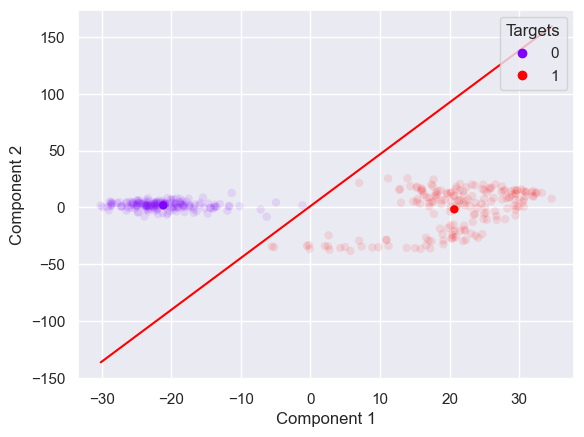

In [10]:
w = np.linalg.pinv(S_W) @ (m[1] - m[0])
w /= np.linalg.norm(w)

plot_scatter(X, t, alpha=0.1,w=w)
plot_scatter(m, [0,1], alpha=1)
plt.show()


### 1.4) Compute and plot the 1D projection of the data
Hint: You can use `seaborn.displot` for a nice visualisation

In [11]:
X_proj = (np.expand_dims(w,axis=1).T @ X.T).T
print(np.shape(X_proj))

(360, 1)


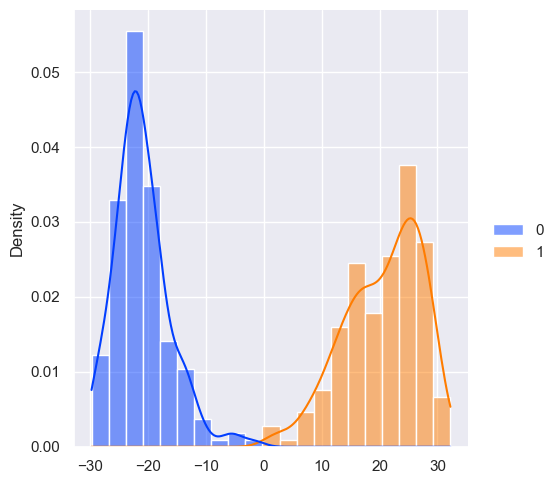

In [12]:
sns.displot(x=np.squeeze(X_proj), hue=t, kde=True, stat='density', kind='hist', binwidth=3)

### 1.5) Compute the class separation of the projected values

In [13]:
abs(w @ (m[0]-m[1]))

41.59631349980379

## 2) Linear Discriminant Analysis (LDA)

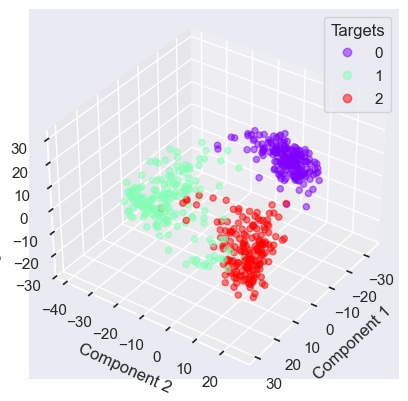

In [14]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
pca = PCA(n_components=3)
X = pca.fit_transform(digits.data)
t = digits.target

plot_scatter3d(X, t, view_point=(35,35))

### 2.1) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
See section 4.1.6 in the textbook or Lecture 15 (slide 17)

In [15]:
mean = np.expand_dims(
    np.array([class_mean(X, t, lbl) for lbl in range(n_class)]),
    axis=1
)

mean_tot = np.average(X, axis=0)

# mean[lbl] is (1, D) after expand_dims, so (mean[lbl]-mean_tot).T @ (mean[lbl]-mean_tot)
# gives the (D, D) outer product; scale by the class count N_k
S_B = sum([
    ((mean[lbl] - mean_tot).T @ (mean[lbl] - mean_tot)) * np.sum(t == lbl)
    for lbl in range(n_class)
])


S_W = sum([
    (X[t==lbl] - mean[lbl]).T @ (X[t==lbl] - mean[lbl])
    for lbl in range(n_class)
])


print("S_B = \n{}".format(S_B))
print("S_W = \n{}".format(S_W))

S_B = 
[[168102.96379919 -19720.58431231 -19025.6580552 ]
 [-19720.58431231  63939.56120285 -18774.4553076 ]
 [-19025.6580552  -18774.4553076    9313.7222212 ]]
S_W = 
[[27768.47732294 19720.58431231 19025.6580552 ]
 [19720.58431231 51486.18362638 18774.4553076 ]
 [19025.6580552  18774.4553076  56959.24487839]]


### 2.2) Compute the projection matrix $\mathbf{W}$
Choose D'=2 (see lecture 15 slide 17 to understand D')

In [16]:
# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W)@S_B)
# Scatter matrices are symmetric PSD, so eigen-quantities are real up to numerical noise
eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)
#eigvals, eigvecs

# Sort them
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]
#eigvals, eigvecs

# construct weight matrix for D'=2
W = eigvecs[:,:2]
W

array([[ 0.91734684, -0.13270419],
       [-0.33360306, -0.82474716],
       [-0.21721827,  0.54971059]])

### 2.3) Compute and plot the 2D projection of the data

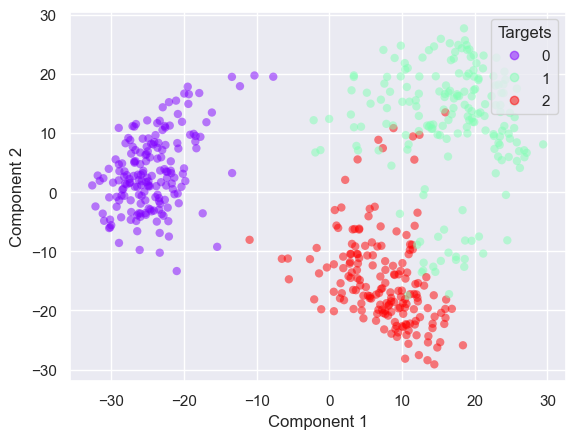

In [17]:
X_proj = (W.T @ X.T).T

plot_scatter(np.array(X_proj), t)

### 2.4) Compute and plot the 2D LDA projection of the original 64D data
Comment on the general utility of the projection as compared to PCA

In [18]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
X = digits.data
t = digits.target

[178, 182, 177]


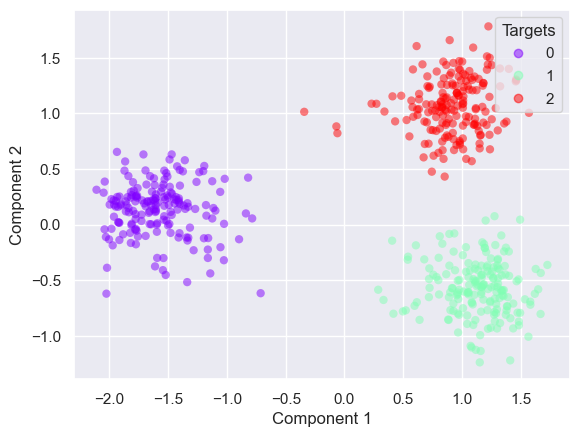

In [19]:
# Compute means
mean = np.expand_dims(
    np.array([class_mean(X, t, lbl) for lbl in range(n_class)]),
    axis=1
)

mean_tot = np.average(X, axis=0)

# Compute scatters
S_B = sum([
    ((mean[lbl] - mean_tot).T @ (mean[lbl] - mean_tot))* np.sum(t==lbl)
    for lbl in range(n_class)
])
print([np.sum(t==lbl) for lbl in range(n_class)])

S_W = sum([
    (X[t==lbl] - mean[lbl]).T @ (X[t==lbl] - mean[lbl])
    for lbl in range(n_class)
])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W)@S_B)
# Scatter matrices are symmetric PSD, so eigen-quantities are real up to numerical noise
eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

# Sort them
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]

# Select the eigenvector corresponding to the two larges eigenvalues
W = eigvecs[:,:2]

# Perform projection
X_proj = (W.T @ X.T).T

# Plot
plot_scatter(X_proj, t)

_Comment on the general utility of the projection as compared to PCA_

* LDA is **supervised**: it uses the class labels to find directions that maximize between-class scatter relative to within-class scatter, so the three digit classes form visibly tighter, better-separated clusters than in the PCA plot at the start of Section 2.
* PCA is **unsupervised**: it maximizes total variance regardless of labels, so its leading components need not separate the classes at all.
* LDA can produce at most $K - 1$ discriminative directions (here $3 - 1 = 2$) and requires labelled data, whereas PCA can produce up to $D$ components from unlabelled data. For visualising or preprocessing *labelled* data for classification, LDA is generally the better projection; for generic dimensionality reduction, PCA is the more flexible tool.

# 3) Constrained Optimization
 
Consider the problem

Minimize: 
$$
f_{min}(x_1, x_2) = (x_1 - 3)^2 + (x_2 - 2)^2
$$

Subject to: 
$$ 
x_1 + x_2 \leq 4 \quad \text{and} \quad x_1 + 4x_2 = 5
$$
where: 
$$f_{min} (x_1, x_2) = (x_1 - 3)^2 + (x_2 - 2)^2$$

## 3.1) Reformulate the problem as a canonical maximization problem
_Use the form described in the end of "Pattern Recognition and Machine Learning" Appendix E._

_NB: Appendix E writes the canonical **maximization** problem with inequality constraints in the form $h(x) \geq 0$ (with $\mu \geq 0$). This exercise's inequality is originally given as $x_1 + x_2 \leq 4$. To match Appendix E's form, define $h(x) = 4 - x_1 - x_2 \geq 0$ — a sign flip of the constraint, **not** an error in the book. Equivalently, if you prefer to keep $h(x) = x_1 + x_2 - 4 \leq 0$, you are using the standard convex-optimization convention from Lecture 16; just be consistent about the sign of $\mu$. Either choice gives the same optimum._

Maximizing $\tilde{f} = -f_{min}$ is equivalent to minimizing $f_{min}$, so the canonical maximization problem is

$$
\text{maximize} \quad \tilde{f}(x_1, x_2) = -f_{min}(x_1, x_2) = -(x_1 - 3)^2 - (x_2 - 2)^2
$$

subject to the equality constraint

$$
g(x_1, x_2) = x_1 + 4x_2 - 5 = 0
$$

and the inequality constraint (in Appendix E form $h \geq 0$)

$$
h(x_1, x_2) = 4 - x_1 - x_2 \geq 0 .
$$

## 3.2) Write out the Lagrangian function
_Use Equation (E.12) in "Pattern Recognition and Machine Learning" Appendix E., and write out all variables_

Using Eq. (E.12), the Lagrangian is

$$
\mathcal{L}(x_1, x_2, \lambda, \mu) = \tilde{f}(x_1, x_2) + \lambda\, g(x_1, x_2) + \mu\, h(x_1, x_2)
$$

$$
= -(x_1 - 3)^2 - (x_2 - 2)^2 + \lambda (x_1 + 4x_2 - 5) + \mu (4 - x_1 - x_2),
$$

with the KKT conditions $\mu \geq 0$ and $\mu\, h(x_1, x_2) = 0$ (complementary slackness).

## 3.3) Compute the gradients with respects to $x_1, x_2$, lagrange multiplier $\lambda$ and the KKT multiplier $\mu$

Setting the gradient of $\mathcal{L}$ to zero gives the stationarity conditions

$$
\frac{\partial \mathcal{L}}{\partial x_1} = -2(x_1 - 3) + \lambda - \mu = 0
$$

$$
\frac{\partial \mathcal{L}}{\partial x_2} = -2(x_2 - 2) + 4\lambda - \mu = 0
$$

together with the constraint conditions

$$
\frac{\partial \mathcal{L}}{\partial \lambda} = g(x_1, x_2) = x_1 + 4x_2 - 5 = 0, \qquad
\mu\, h(x_1, x_2) = 0, \quad \mu \geq 0, \quad h(x_1, x_2) \geq 0 .
$$

### 3.4) Compute the optimum
_Hint: Set it up as a system of linear equations and solve it using Gaussian Elimination (e.g. using `scipy.linalg.solve`)._

Here $\tilde{f} = -f_{min}$ is the maximization objective from step 3.1, and $h(x) = 4 - x_1 - x_2 \geq 0$.

Follow these steps:

1. **Assume the inequality constraint \( h(x) \) is inactive.**  
   - Set its KKT multiplier to zero (\( \mu = 0 \)).  
   - Include only the equality constraint \( g(x) = 0 \) in your formulation.  
   - Construct the system of equations from the KKT conditions:  
     \[
     \nabla \tilde{f}(x) + \lambda \nabla g(x) = 0, \quad g(x) = 0
     \]
   - Solve for \( x_1, x_2, \lambda \) using `scipy.linalg.solve`.

2. **Check the inequality constraint.**  
   - Evaluate \( h(x_1, x_2) \).  
   - If \( h(x_1, x_2) > 0 \), the constraint is inactive — keep this as your final solution.

3. **If the inequality is violated** (\( h(x_1, x_2) < 0 \)):  
   - Reformulate the problem assuming \( h(x) \) is **active** (\( h(x) = 0 \)).  
   - Include both constraints in the Lagrangian:  
     \[
     \mathcal{L}(x_1, x_2, \lambda, \mu) = \tilde{f}(x_1, x_2) + \lambda g(x_1, x_2) + \mu h(x_1, x_2)
     \]
   - Construct the corresponding system of equations:
     \[
     \nabla \tilde{f}(x) + \lambda \nabla g(x) + \mu \nabla h(x) = 0, \quad g(x) = 0, \quad h(x) = 0
     \]
   - Solve for \( x_1, x_2, \lambda, \mu \) using `scipy.linalg.solve`.

_The correct optimum is the solution that satisfies all constraints and yields the lowest \( f_{min}(x) \)._


In [20]:
# Assuming that h(x) is inactive (mu = 0), solve the maximization KKT system with the
# equality constraint only:  grad f_tilde + lambda grad g = 0,  g = 0.
# f_tilde = -f_min, so d f_tilde/dx1 = -2(x1-3) and d f_tilde/dx2 = -2(x2-2).
A = np.array([[ -2, 0, 1],
              [ 0, -2, 4],
              [ 1,  4, 0]])
b = [[-6],
     [-4],
     [5]]

x_1, x_2, lbda = scipy.linalg.solve(A,b)[:,0]

print("x_1 = {}".format(x_1))
print("x_2 = {}".format(x_2))
print("lambda = {}".format(lbda))

def f(x1,x2): return (x1 - 3)**2 + (x2 - 2)**2
def g(x1,x2): return x1 + 4*x2 - 5
def h(x1,x2): return 4 - x1 - x2   # Bishop convention: feasible requires h(x) >= 0

print(f"min f(x) = {f(x_1,x_2)}")
print(f"g(x) = {g(x_1,x_2)}")
print(f"h(x) = {h(x_1,x_2)}")
# h(x) = 13/17 > 0, so the inequality is inactive and this is the optimum.

x_1 = 2.6470588235294117
x_2 = 0.5882352941176471
lambda = -0.7058823529411764
min f(x) = 2.117647058823529
g(x) = 0.0
h(x) = 0.7647058823529412
